In [4]:
!mkdir -p data/cucumber-9-p2-python
!curl -L -o data/cucumber-9-p2-python.tar.gz https://github.com/workpiles/CUCUMBER-9/raw/master/prototype_2/cucumber-9-p2-python.tar.gz
!tar -xvzf data/cucumber-9-p2-python.tar.gz -C data/cucumber-9-p2-python

x batches.meta
x data_batch_1
x data_batch_2
x data_batch_3
x data_batch_4
x data_batch_5
x data_batch_6


In [13]:
import pickle
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

data = unpickle("data/cucumber-9-p2-python/data_batch_1")
data.keys()

dict_keys([b'data', b'labels', b'batch_label', b'filenames'])

b'L_00602'


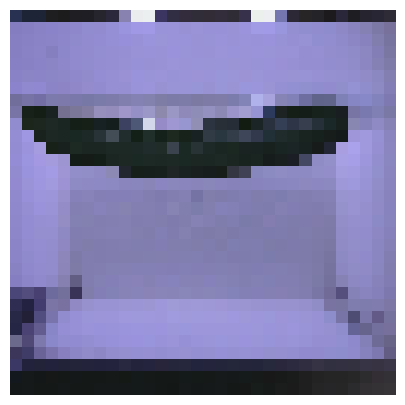

Sample Image 'b'C_00536'' with 3 Views


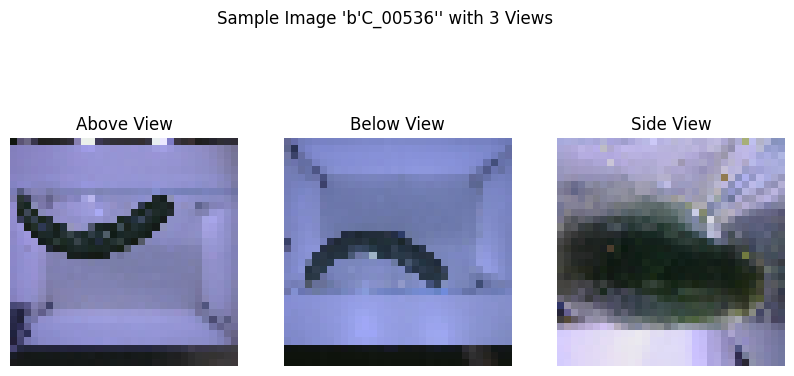

Sample Image 'b'L_00602'' with 3 Views


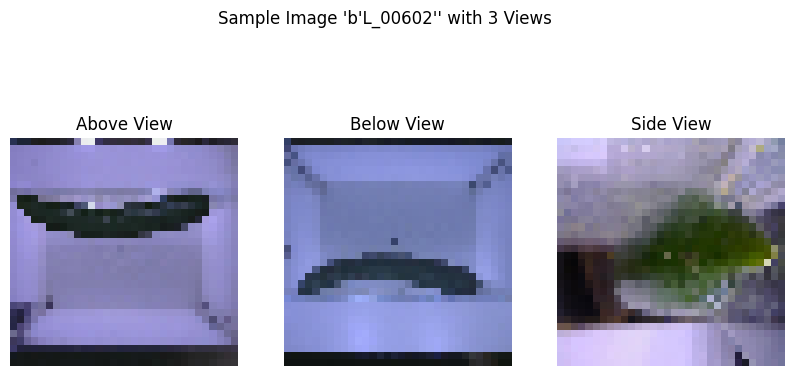

Sample Image 'b'C_00644'' with 3 Views


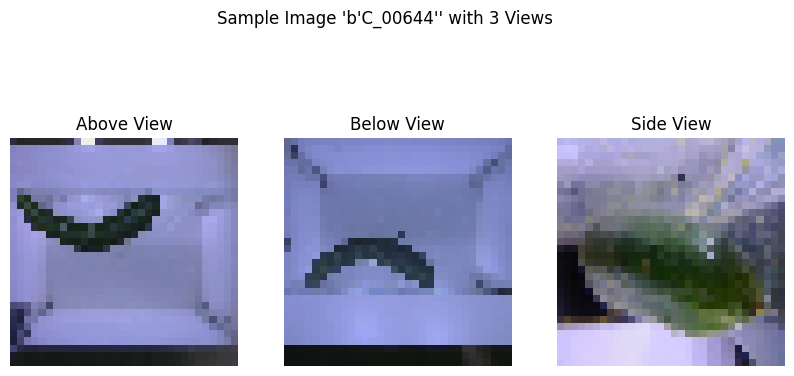

Sample Image 'b'BC_00234'' with 3 Views


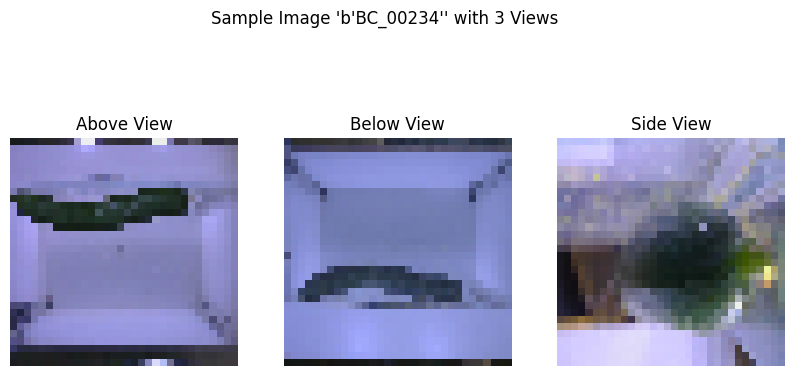

Sample Image 'b'C_00200'' with 3 Views


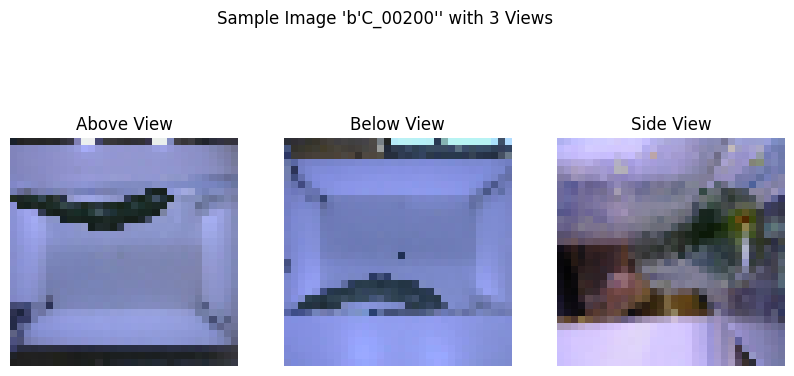

Sample Image 'b'M_00332'' with 3 Views


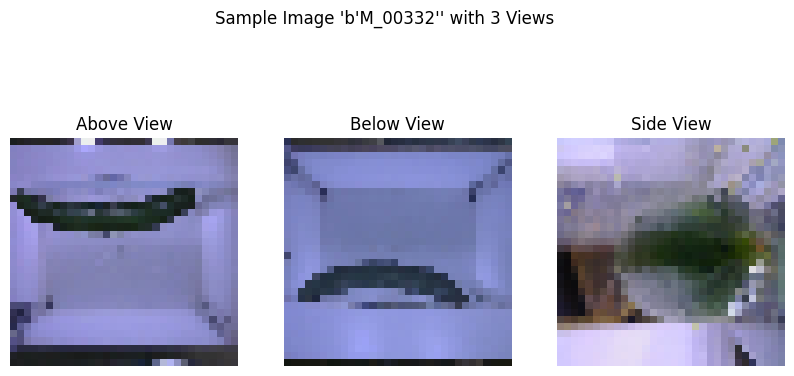

Sample Image 'b'SETTING_00153'' with 3 Views


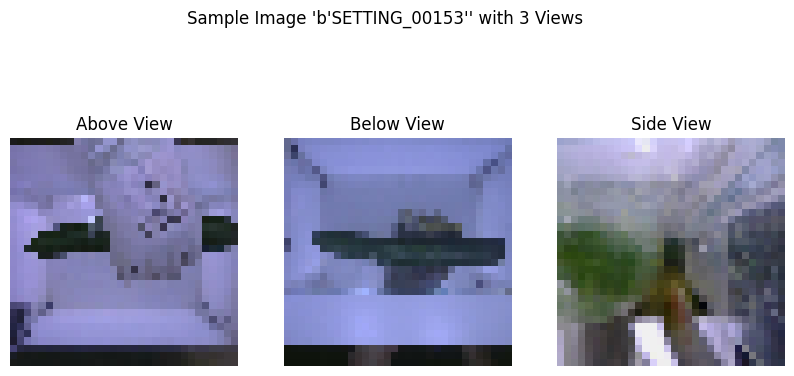

Sample Image 'b'BC_00078'' with 3 Views


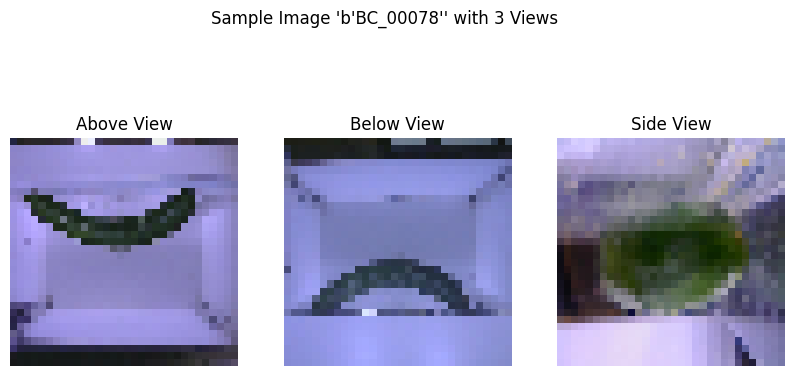

Sample Image 'b'L_00223'' with 3 Views


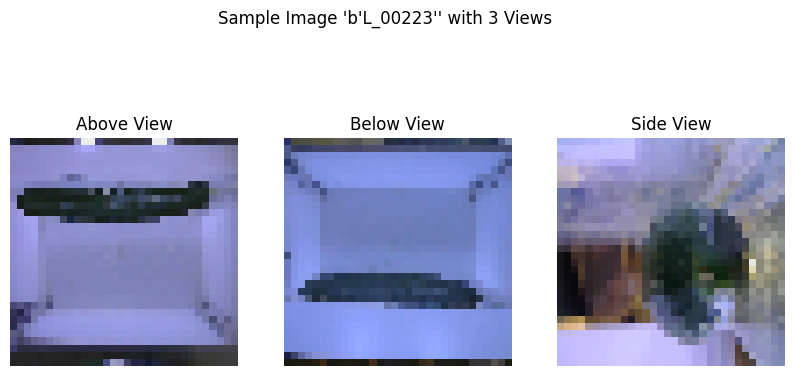

Sample Image 'b'SETTING_00262'' with 3 Views


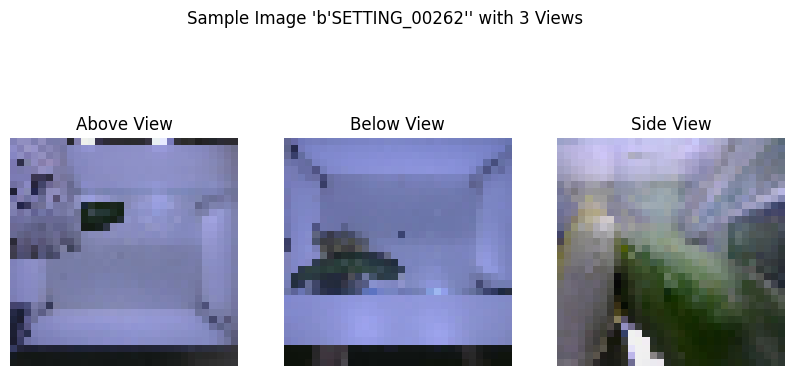

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Extract data and labels
raw_data = data[b"data"]  # Shape: (12600, 1024)
labels = np.array(data[b"labels"])  # Shape: (12600,)
filenames = data[b"filenames"]

# Reshape to (8400, 9, 32, 32)
num_images = raw_data.shape[0] // 9  # 12600 / 9 = 1400 images
image_size = 32
images = raw_data.reshape(num_images, 9, image_size, image_size)

# Convert to (8400, 32, 32, 9) for visualization
images = images.transpose(0, 2, 3, 1)  # (8400, 32, 32, 9)

# Ensure dtype is compatible with imshow()
images = images.astype(np.uint8)  # Convert to 8-bit integer (0-255)

# Display a sample image with its three views
def show_image(img_array, title="Image"):
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    # Extract views
    above = img_array[:, :, 0:3]  # First 3 channels
    below = img_array[:, :, 3:6]  # Next 3 channels
    side  = img_array[:, :, 6:9]  # Last 3 channels

    # Show images
    axes[0].imshow(above)
    axes[0].set_title("Above View")
    
    axes[1].imshow(below)
    axes[1].set_title("Below View")
    
    axes[2].imshow(side)
    axes[2].set_title("Side View")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(title)
    plt.show()

## Take one image
fig, axes = plt.subplots(1, 1, figsize=(10, 5))
axes.axis("off")
image = images[1]
filename = filenames[1]
print(filename)
axes.imshow(image[:, :, 0:3])
plt.show()

# Display all images
for filename, image, _ in zip(filenames, images, range(10)):
    print(f"Sample Image '{filename}' with 3 Views")
    show_image(image, f"Sample Image '{filename}' with 3 Views")